# VIMA minimal demo

In [ ]:
# Install dependencies (only needed on Google Colab or fresh environments)
!pip install vima-spatial adjustText -q

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import glob, os
import pandas as pd
import vima
import torch
np.random.seed(0)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
torch.set_default_device(device)

## 0. Download data

There are two archives to download.

The first contains the sample metadata table (`samplemeta.tsv` with case/control labels), a cell segmentation table (`cells.tsv`) that is not required to run `vima` but that is helpful for interpreting the results, and a set of pre-computed `vima` patch fingerprints (`fingerprints.h5ad`) for users to want to be able to skip the pre-processing and model training sections of the demo and skip straight to the [case-control analysis](#3-case-control-analysis).

The second contains the 10 raw transcript parquet files (one per tissue section) for users who want to run the [preprocessing](#1-Preprocess-data) and [model training](#2-Model-training) sections.



In [2]:
import requests
from tqdm.notebook import tqdm

def download_zenodo(record_id, target_dir):
    r = requests.get(f"https://zenodo.org/api/records/{record_id}")
    files = r.json()["files"]
    os.makedirs(target_dir, exist_ok=True)
    for i, f in enumerate(files):
        url = f["links"]["self"]
        fname = f["key"]
        size = f.get("size", 0)
        with requests.get(url, stream=True) as r:
            with open(f"{target_dir}/{fname}", "wb") as out, \
                tqdm(total=size, unit='B', unit_scale=True,
                    desc=f"[{i+1}/{len(files)}] {fname}") as pbar:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    out.write(chunk)
                    pbar.update(len(chunk))

In [5]:
# download sample metadata, cell metadata, and precomputed vima fingerprints (~300MB, quicker download) 
download_zenodo("21535534", "./data/ST")

[1/3] samplemeta.tsv:   0%|          | 0.00/295 [00:00<?, ?B/s]

[2/3] cells.tsv:   0%|          | 0.00/43.2M [00:00<?, ?B/s]

[3/3] fingerprints.h5ad:   0%|          | 0.00/244M [00:00<?, ?B/s]

Having downloaded the above files, you can now skip to [case-control analysis](#3-case-control-analysis) if you want to see deliverables right away. If you want to run the full workflow end-to-end, download the next archive and continue from there.

In [ ]:
# download raw data (~450MB per sample, can take ~20-40 minutes)
download_zenodo("20433752", "./data/ST/raw")

[1/12] H21.33.001_1192523789.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

[2/12] H21.33.031_1296510469.parquet:   0%|          | 0.00/957M [00:00<?, ?B/s]

[3/12] samplemeta.tsv:   0%|          | 0.00/295 [00:00<?, ?B/s]

[4/12] cells.tsv:   0%|          | 0.00/43.2M [00:00<?, ?B/s]

[5/12] H21.33.015_1162693727.parquet:   0%|          | 0.00/321M [00:00<?, ?B/s]

...

[8/12] H20.33.035_1194111807.parquet:   0%|          | 0.00/593M [00:00<?, ?B/s]

[9/12] H21.33.001_1192523794.parquet:   0%|          | 0.00/454M [00:00<?, ?B/s]

[10/12] H21.33.001_1217500590.parquet:   0%|          | 0.00/421M [00:00<?, ?B/s]

[11/12] H21.33.014_1217501462.parquet:   0%|          | 0.00/565M [00:00<?, ?B/s]

[12/12] H20.33.040_1195928141.parquet:   0%|          | 0.00/254M [00:00<?, ?B/s]

# 1. Preprocess data

In [3]:
resolution = 10 #microns per pixel
nmetamarkers = 10 # desired number of meta-markers
transcriptfiles = glob.glob(f'data/ST/raw/*.parquet')
outdir = f'data/ST/{resolution}u'

# Define a function that reads in the raw transcript data for one sample and
# returns a tuple of (sample_id, dataframe)
# Note: blank probes and low-quality genes/transcripts should already be removed before this step
def load(path):
    sid = os.path.basename(path).replace('.parquet', '')
    data = pd.read_parquet(path) # can replace with read_csv as appopriate, but parquet is faster
    return sid, data

In [5]:
# load transcript files and rasterize into counts per pixel
vima.pp.st.prepare_merfish(load=load,
                           filepaths=transcriptfiles,
                           x_col='global_x',
                           y_col='global_y',
                           gene_col='gene',
                           outdir=outdir,
                           pixel_size=resolution,
                           basic_plots=False)

# convert markers to meta-markers
repname = f'metamarkers_{nmetamarkers}'
allpixels_pca, pc_loadings = vima.pp.pca_pixels(outdir, repname, nmetamarkers=nmetamarkers, plot=False)

# harmonize the meta-markers and write the results
harmpixels = vima.pp.harmonize(allpixels_pca, plot=False)
vima.pp.write_harmonized(outdir, repname, harmpixels)

Computing normalization factor...
	Processing sample 1/10: H21.33.001_1192523789 (13.65M tx) → median 26.0 transcripts per pixel with >=10 transcripts
	Processing sample 2/10: H21.33.015_1162693727 (9.52M tx) → median 27.0 transcripts per pixel with >=10 transcripts
	Processing sample 3/10: H20.33.035_1194111812 (19.28M tx) → median 37.0 transcripts per pixel with >=10 transcripts
	Processing sample 4/10: H21.33.031_1296510469 (29.63M tx) → median 35.0 transcripts per pixel with >=10 transcripts
	Processing sample 5/10: H21.33.031_1296510477 (15.92M tx) → median 34.0 transcripts per pixel with >=10 transcripts
	Processing sample 6/10: H20.33.035_1194111807 (17.41M tx) → median 35.0 transcripts per pixel with >=10 transcripts
	Processing sample 7/10: H21.33.001_1192523794 (13.34M tx) → median 25.0 transcripts per pixel with >=10 transcripts
	Processing sample 8/10: H21.33.001_1217500590 (13.93M tx) → median 24.0 transcripts per pixel with >=10 transcripts
	Processing sample 9/10: H21.33

100%|███████████████████████████████████████████████████████████████| 10/10 [00:37<00:00,  3.73s/it]


merging and standardizing metapixels
Metapixel matrix: 2,000,000 pixels × 140 features
performing PCA...

top/bottom features per PC (features with negative loadings preceded by "-"):
     PC1       PC2      PC3      PC4     PC5      PC6    PC7      PC8       PC9     PC10
 SECRET6      CD74  SECRET5     EBF1 SLC32A1     CUX2   NRG1    CSMD1    STXBP6    HTR2A
SECRET11   SECRET5  L3MBTL4      DCN    SOX6    LAMP5   EYA4      TNR     FGF12    PDE4B
 SECRET4       ID3     EYA4  NOSTRIN    DLX1     SV2C   SOX6     DGKG   SECRET3     RORB
SECRET20     PDE4B  SECRET6    LAMA4    RYR3   HS6ST3 SCUBE1    CBLN2    ATRNL1   HS3ST2
SECRET16      DLC1   SORCS3    PALMD  BTBD11   CARTPT  CBLN2 CACNA2D3     ITGB8      TOX
 -HS3ST2 -SECRET18    -RYR3  -SEMA6D -HS3ST2     -TOX   -TOX    -CTSS     -CD74   -FGF13
 -ATRNL1  -SECRET2 -SLC14A1  -HS6ST3   -CDH6   -ASTN2 -ZMAT4    -GAD2    -TACR1   -CBLN2
  -SATB2 -SECRET19  -CACHD1 -SECRET5   -CD74   -LRP1B   -DCC    -RORB   -SORCS3    -LHX6
 -GRIN2A -SECRE

100%|███████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.63s/it]


Running Harmony...


2026-07-24 07:13:21,825 - harmonypy - INFO - Running Harmony
2026-07-24 07:13:21,825 - harmonypy - INFO -   Parameters:
2026-07-24 07:13:21,826 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-24 07:13:21,826 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-24 07:13:21,826 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-24 07:13:21,826 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-24 07:13:21,827 - harmonypy - INFO -     nclust: 100
2026-07-24 07:13:21,827 - harmonypy - INFO -     block_size: 0.05
2026-07-24 07:13:21,827 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-24 07:13:21,828 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-07-24 07:13:21,828 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-24 07:13:21,828 - harmonypy - INFO -     verbose: True
2026-07-24 07:13:21,829 - harmonypy - INFO -     random_state: 0
2026-07-24 07:13:21,829 - harmonypy - INFO -   Data: 10 PCs × 2426365 cells
2026-07-24 07:13:21,829 

# 2. Model training

In [6]:
# read in samples
samples = vima.read_samples(f'data/ST/10u/metamarkers_10/*.nc')

# choose initial set patches to train on and a smaller set of denser patches to refine training on
P = vima.PatchCollection(samples)
Pdense = P.refined(max_frac_empty=0.5)

100%|███████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.03it/s]


[PatchCollection: in pytorch mode]
[PatchCollection: data augmentation is off]


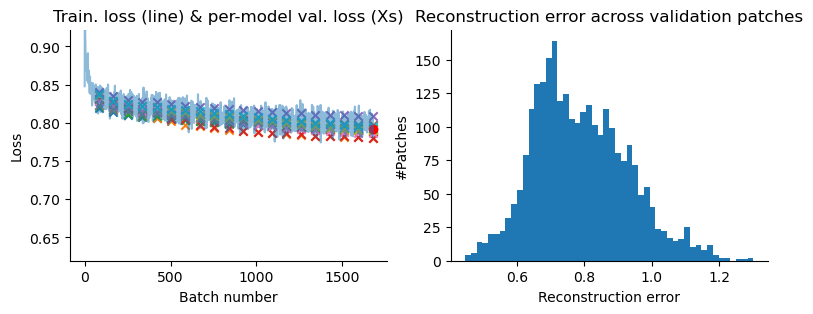

End of epoch 20
Avg. val. loss: 0.7920428693294526
Time elapsed this epoch: 189.69 sec
Total time elapsed: 3825.18 sec
Per-channel MSE (% of variance): 0.42 (42%), 0.64 (64%), 0.89 (89%), 0.84 (84%), 0.82 (82%), 0.75 (75%), 0.84 (84%), 0.89 (89%), 0.92 (92%), 0.88 (88%)
Best val. losses so far: 0.79, 0.78, 0.79, 0.78, 0.81, 0.8, 0.79, 0.8, 0.79, 0.8
Best epoch so far: 20, 20, 20, 20, 20, 20, 20, 20, 20, 20



In [7]:
# train the model and save results
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes)
log_all, log_dense = vima.fit(models, P, Pdense)
torch.save(models.state_dict(), f'data/ST/weights.pt')

In [8]:
# read in model weights and create patch fingerprints
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes, weights='data/ST/weights.pt')
ds = vima.latentreps(models, Pdense)

# add in patch-level metadata like cell type counts and avg expression, for downstream interpretation
cells = pd.read_csv('data/ST/cells.tsv', sep='\t')
ds.obsm['abundances'] = vima.cell_type_counts(cells, ds.obs,
    'sid', 'subclass_name', 'x', 'y')
ds.obsm['expr'] = vima.expression_profiles('data/ST/10u/normalized', ds.obs)

# write fingerprints to file
ds.write_h5ad(f'data/ST/fingerprints.h5ad')

applying models
[PatchCollection: in pytorch mode]
[PatchCollection: data augmentation is off]


100%|███████████████████████████████████████████████████████████████| 28/28 [00:40<00:00,  1.46s/it]


computing nearest-neighbor graphs


expression_profiles: 100%|██████████████████████████████████████████| 10/10 [00:12<00:00,  1.21s/it]


# 3. Case-control analysis

computing MAT


100%|███████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.35it/s]


performing association test
P = 0.007899210078992101
Computing UMAP...


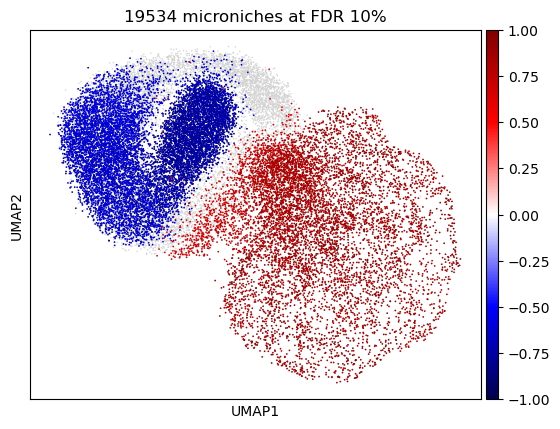

In [9]:
# read in fingerprints and sample metadata
ds = vima.Fingerprints.read_h5ad('data/ST/fingerprints.h5ad')
samplemeta = pd.read_csv('data/ST/samplemeta.tsv', sep='\t').set_index('sid', drop=True)

# association test
p, D = vima.association(ds, samplemeta.case, 'sid') # TODO: include comment about donorids
vima.v.plot_association(D)

# label significant results
D.obs['sig_pos'] = (D.obs.mncoef > 0) & (D.obs.mncoef_fdr <= 0.1)
D.obs['sig_neg'] = (D.obs.mncoef < 0) & (D.obs.mncoef_fdr <= 0.1)
D.write('data/ST/association_results.h5ad')

Strength of association between patch fingerprints and case status, plotted in space.
Each point is a patch, colored by the strength of association.
(red = positive association, blue = negative association).


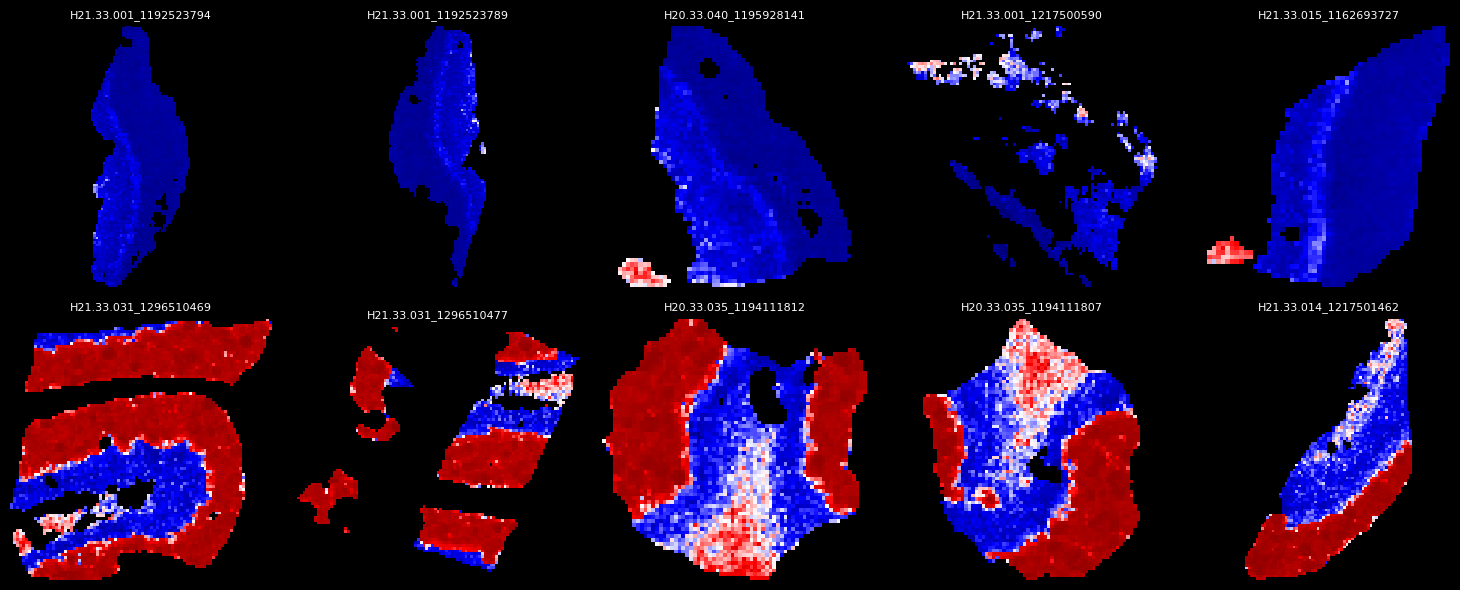

In [10]:
# visualize results in space
print('Strength of association between patch fingerprints and case status, plotted in space.' \
'\nEach point is a patch, colored by the strength of association.'
'\n(red = positive association, blue = negative association).')
vima.v.spatialplot(D.obs, D.obs.mncoef,
                    sids=samplemeta.sort_values(by='case').index, # sort samples by case status
                    cmap='seismic', vmin=-1, vmax=1);

# 4. Interpretation

In [11]:
# compute enrichments for all cell types between case-associated patches and rest
# we find that the case-associated patches are rich in L2/3 IT neurons and VIP interneurons,
# suggesting that they are concentrated in cortical layers 2 and 3
ct_enrichments = vima.test_features(D.obsm['abundances'],
              D.obs.sig_pos, unit_of_analysis=D.obs.sid)
sig_ct_enrichments = ct_enrichments[ct_enrichments.pvals_adj <= 0.1].sort_values(by='diff_median', ascending=False)
print('Most enriched cell types are:', sig_ct_enrichments.iloc[0].name, 'and', sig_ct_enrichments.iloc[1].name,
      f'\nwith log2fc\'s of {sig_ct_enrichments.iloc[0].log2fc:.2f} and',
      f'{sig_ct_enrichments.iloc[1].log2fc:.2f} respectively,'
      f'\nand adjusted P-values of {sig_ct_enrichments.iloc[0].pvals_adj:.3f} and {sig_ct_enrichments.iloc[1].pvals_adj:.3f}', 'respectively.')

Comparing 8227 patches (Group A) to 18890 patches (Group B).
Most enriched cell types are: L2/3 IT and Vip 
with log2fc's of 5.22 and 2.75 respectively,
and adjusted P-values of 0.010 and 0.010 respectively.


Comparison of cell type abundances between case-associated and control-associated patches:


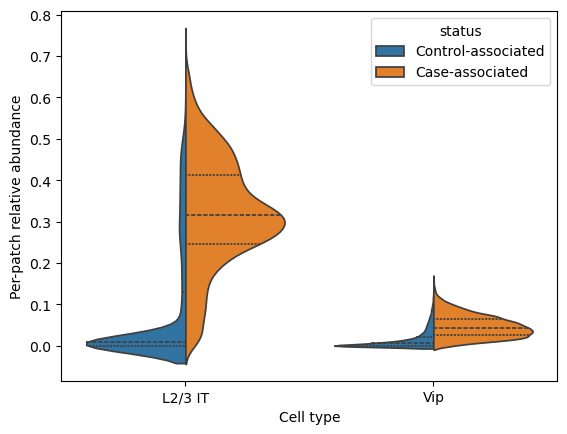

In [12]:
# visualize abundance differences between case-associated patches and rest, for top 2 cell types
print('Comparison of cell type abundances between case-associated and control-associated patches:')
vima.v.plot_features(D.obsm['abundances'],
                     D.obs.sig_pos,
                     n_top=2, n_bottom=0,
                     markers=sig_ct_enrichments.index,
                     labels=['Case-associated', 'Control-associated'],
                     show=False
                     )
plt.ylabel('Per-patch relative abundance')
plt.xlabel('Cell type')
plt.show()

Spatial abundance of L2/3 IT cells with case-associated patches outlined in red
(control samples on top, case samples on bottom):
We see that the case-associated patches (outlined in red) are mostly concentrated in the L2/3-rich  
areas of the tissue in case samples, suggesting that vima is picking up on changes in these layers.


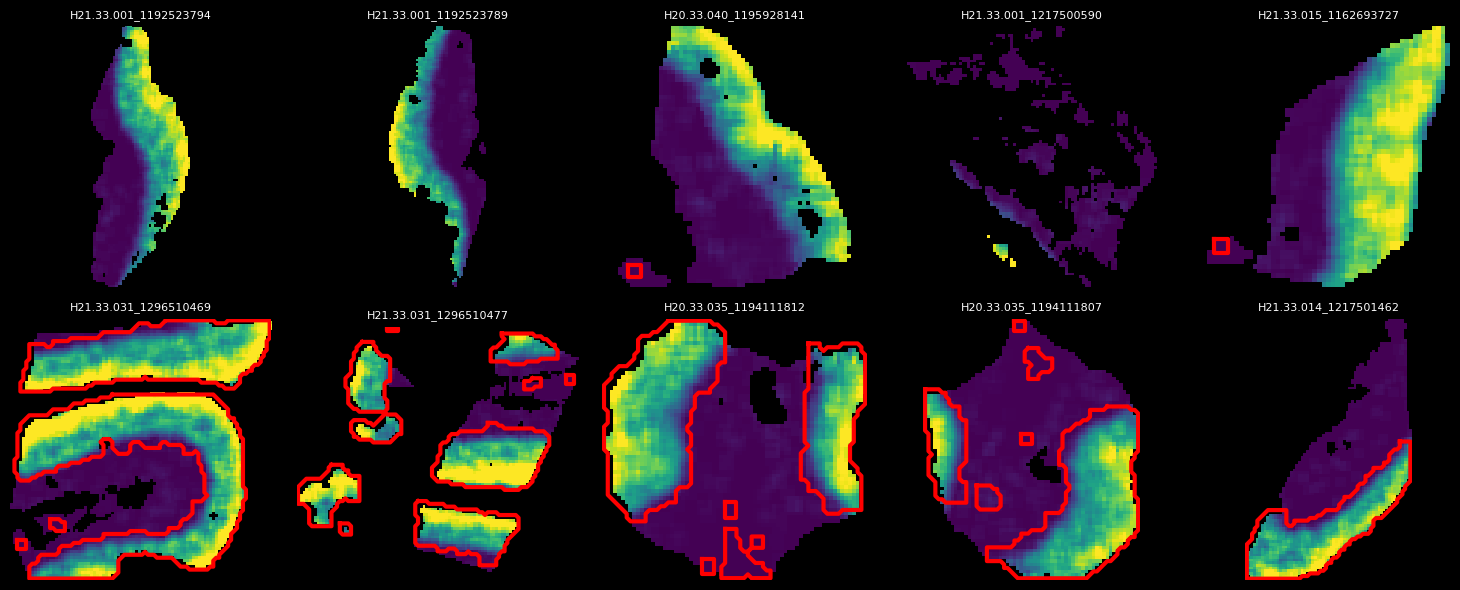

In [13]:
# visualize case-associated patches vs L2/3-rich patches in space
print('Spatial abundance of L2/3 IT cells with case-associated patches outlined in red')
print('(control samples on top, case samples on bottom):')
vima.v.spatialplot(D.obs, D.obsm['abundances']['L2/3 IT'],
                    sids=samplemeta.sort_values(by='case').index, # sort samples by case status
                    cmap='viridis',
                    show=False)
vima.v.annotate_spatialplot(D.obs, D.obs.sig_pos, 'red', show=False);
print('We see that the case-associated patches (outlined in red) are mostly concentrated in the L2/3-rich ',
       '\nareas of the tissue in case samples, suggesting that vima is picking up on changes in these layers.')

Comparing 7954 patches (Group A) to 4929 patches (Group B).


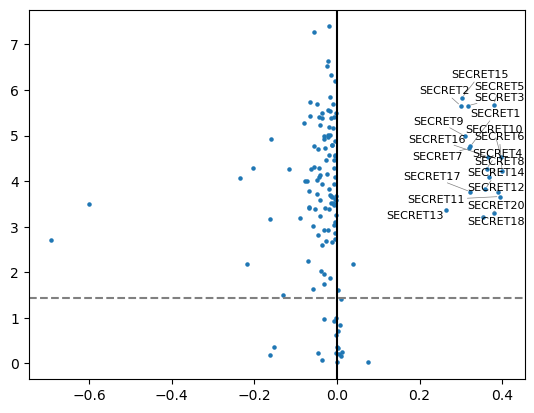

Aha - Layer 2/3 in the case samples has elevated expression of these SECRET genes!


In [19]:
# What is it about the layer 2/3 patches in the case samples that makes vima pick them up?
# Let's find out by comparing expression of all genes between 
# case-associated L2/3 IT-rich patches and control-associated L2/3 IT-rich patches
l23 = D.obsm['abundances']['L2/3 IT'] > 0.05
l23_sig_pos = D.obs.sig_pos & l23
l23_sig_neg = D.obs.sig_neg & l23
ge_enrichments = vima.test_features(D.obsm['expr'],
              l23_sig_pos, l23_sig_neg, unit_of_analysis=D.obs.sid,
              Ttest=True # here we use a T-test instead of the default permutation test
                         # in order to demonstrate this feature, which is appropriate for smaller
                         # datasets where permutation tests may not be well-powered.
                         # In practice in this example it will also work to set Ttest=False
                         # but the P-values will just be less impressive
              )
sig_ge_enrichments = ge_enrichments[ge_enrichments.pvals_adj <= 0.05].sort_values(by='diff_median', ascending=False)

# make volcano plot
from adjustText import adjust_text
plt.scatter(ge_enrichments.diff_median, -np.log10(ge_enrichments.pvals), s=5)
to_label = ge_enrichments[ge_enrichments.diff_median > 0.2]
texts = [plt.text(row.diff_median, -np.log10(row['pvals']), idx, fontsize=8)
         for idx, row in to_label.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
plt.axhline(-np.log10(sig_ge_enrichments.pvals.max()*0.95), c='gray', linestyle='--')
plt.axvline(x=0, c='black')
plt.show()
print('Aha - Layer 2/3 in the case samples has elevated expression of these SECRET genes!')

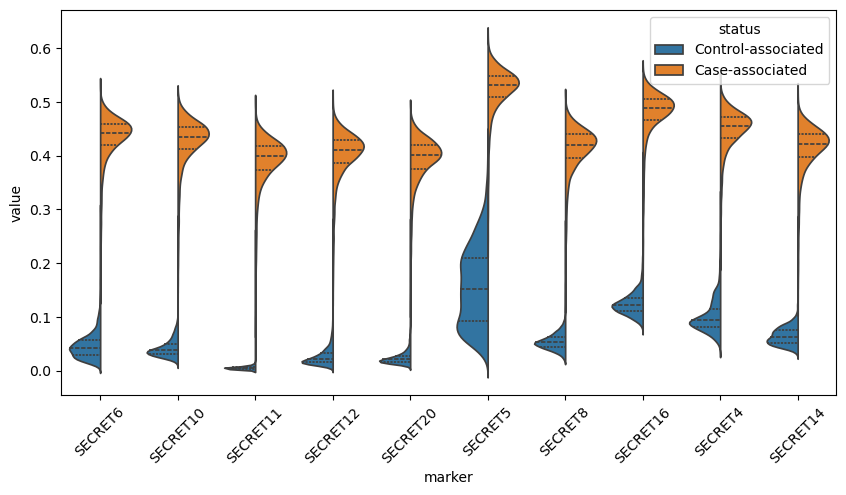

In [15]:
# Look at distribution of expression of top SECRET genes in
# case-associated L2/3 patches vs control-associated of L2/3 patches
plt.figure(figsize=(10, 5))
vima.v.plot_features(D.obsm['expr'],
                     l23_sig_pos,
                     l23_sig_neg,
                     n_top=10, n_bottom=0,
                     markers=sig_ge_enrichments.index,
                     labels=['Case-associated', 'Control-associated'],
                     show=False
                     )
plt.xticks(rotation=45)
plt.show()

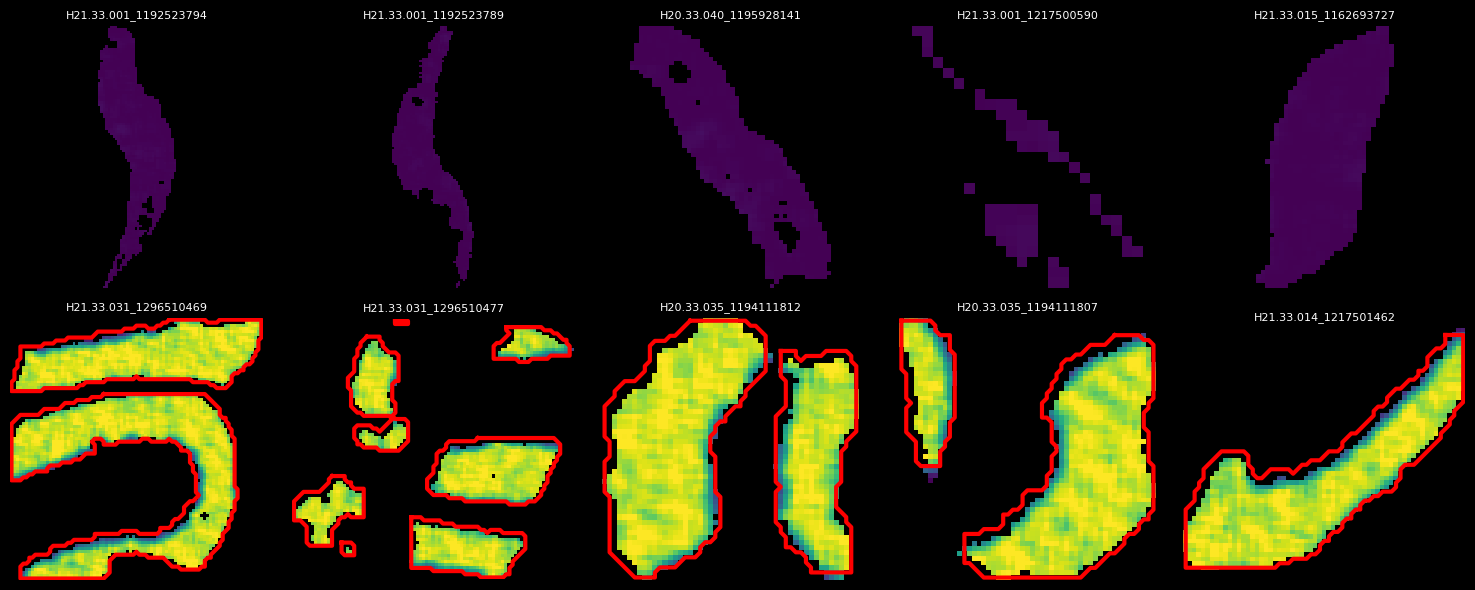

In [16]:
# let confirm this another way: by visualizing the distribution of expression
# of SECRET11 in space, restricting just to layer 2/3 of each sample
vima.v.spatialplot(D.obs[l23], D.obsm['expr'][l23]['SECRET11'],
                               cmap='viridis', sids=samplemeta.sort_values(by='case').index,
                               show=False)
vima.v.annotate_spatialplot(D.obs[l23], D.obs[l23].sig_pos, 'red');

Adding 2 markers: 0it [00:00, ?it/s]
Reading samples: 100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 139345.65it/s]


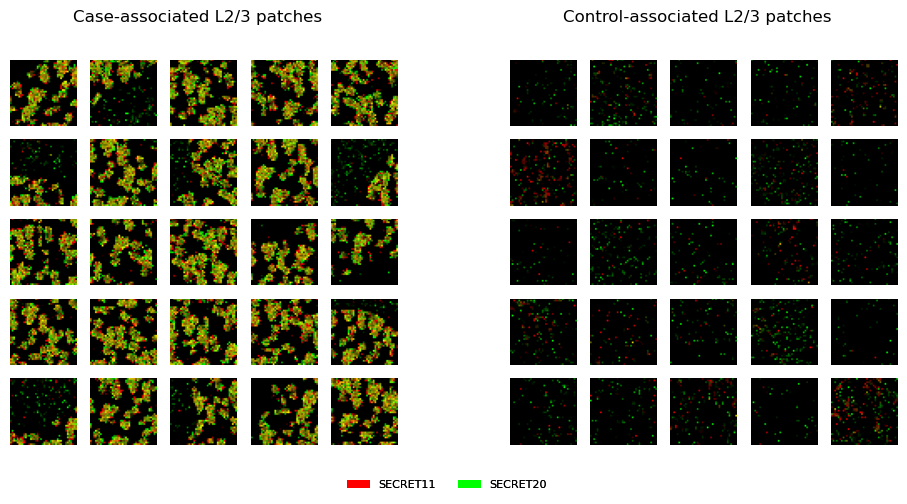

In [17]:
# visualize composite images of case-associated and control-associated patches
# for the two most differentially expressed genes, SECRET11 and SECRET20
fig = plt.figure(figsize=(10, 5))
sf_pos, sf_neg = fig.subfigures(1, 2)
sf_pos.suptitle('Case-associated L2/3 patches')
sf_neg.suptitle('Control-associated L2/3 patches')
vima.v.show_patches_composite(
    patchmeta = D.obs[D.obs.sig_pos],
    markers   = ['SECRET11','SECRET20'],
    directory = 'data/ST/10u/normalized',
    features = D.X[D.obs.sig_pos],
    nx=5, ny=5, subfig=sf_pos, show=False
)
vima.v.show_patches_composite(
    patchmeta = D.obs[D.obs.sig_neg],
    markers   = ['SECRET11','SECRET20'],
    directory = 'data/ST/10u/normalized',
    features = D.X[D.obs.sig_neg],
    nx=5, ny=5, subfig=sf_neg);

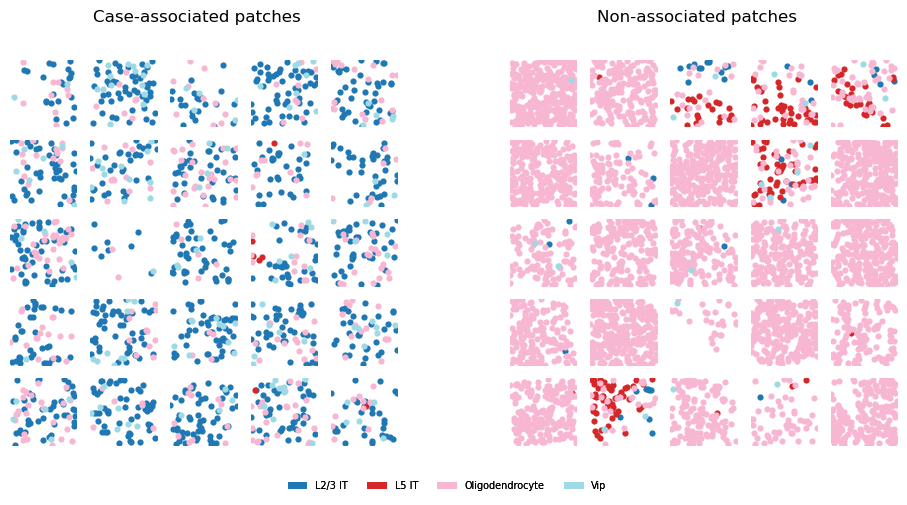

In [18]:
# visualize example case- and non-associated patches using the segmented cells
cells = pd.read_csv('data/ST/cells.tsv', sep='\t')
types_to_show = list(sig_ct_enrichments.index[:2]) + list(sig_ct_enrichments.index[-2:])

fig = plt.figure(figsize=(10, 5))
sf_pos, sf_neg = fig.subfigures(1, 2)
sf_pos.suptitle('Case-associated patches')
sf_neg.suptitle('Non-associated patches')
vima.v.show_patches_cells(D.obs[D.obs.mncoef > 0.8], cells,
                          include_only=types_to_show, # show only the top 5 enriched cell types for clarity
                          x_col='x', y_col='y', celltype_col='subclass_name',
                          pixelsize_microns=10, s=20, subfig=sf_pos, show=False)
vima.v.show_patches_cells(D.obs[D.obs.mncoef.abs() <= 0.2], cells,
                          include_only=types_to_show, # show only the top 5 enriched cell types for clarity
                          x_col='x', y_col='y', celltype_col='subclass_name',
                          pixelsize_microns=10, s=20, subfig=sf_neg);